# Experimento 107 — mezcla PSBP con átomos GP sobre la curva

**Prototipo, fuera del pipeline canónico.** No sigue la estructura de la corrida 61:
un solo notebook, sin FPCA, sin MATLAB y sin barrido en `M`. El muestreador vive en
`mezcla_gp_funcional.py`, en esta misma carpeta, junto con la especificación completa del modelo.

$$
a_t\mid S_t=h,\ x_t\sim\mathcal N_K\!\big(A_h^\top x_t,\ \sigma_h^2S(\ell_h)+s_h^2I\big),\qquad
\Pr(S_t=h\mid x_t)=\pi_h(x_t),\quad \eta_h=\alpha_h+\omega_h^\top z_t .
$$

Aquí $a_t$ son los $K$ coeficientes de la curva en una base ortonormal. Cada átomo es un GP
sobre la curva, con media FAR propia del régimen, y hay **una** asignación $S_t$ por curva.

**Escenario 107 = Algoritmo C-1 del anexo** (`sim_escenario_C.config_C1`). Los coeficientes de
Fourier son el dato, y la respuesta $\tilde a_{t,2}$ depende **cuadráticamente** de los rezagos
2–5 de $\tilde a_{t,1}$. Esa brecha no lineal, $b^2=0.25$, es la que un FAR no puede alcanzar.

## §1 Imports y rutas

In [1]:
import time
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_psbp_fd.utils.rutas import experiment_id, construir_paths
from model_psbp_fd.pipelines import (
    config_C1, generar_escenario_C, contabilidad_varianzas, curvas_truncadas,
    base_fourier, guardar_escenario, guardar_curvas, cargar_curvas,
    cargar_curvas_true, guardar_config_evaluacion, cargar_config_evaluacion,
)
from model_psbp_fd.fit.rolling import ventana_movil_funcional
from model_psbp_fd.fit.diagnostics_mcmc import diagnostico_variable

import mezcla_gp_funcional as mgp

### §1.1 `[CONFIG]` experimento

In [2]:
# -- Identificador ------------------------------------------------------------
# BASENAME propio ("experimento_107", no "escenario_107") para que este
# prototipo no pise a una futura corrida canonica 107 con la estructura de la 61.
BASENAME     = "experimento_107"
ESCENARIO_ID = 1            # Algoritmo C-1 del anexo
REPLICA_ID   = 1
J_BASE       = 10           # terminos de Fourier (anexo: J = 10)
M_COEF       = J_BASE       # el modelo usa TODOS los coeficientes: no hay truncamiento
EXPERIMENT_ID = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M_COEF)

# -- Esquema comun de las corridas vivas --------------------------------------
L_GRILLA   = 75
T_CURVAS   = 1000
PROP_TRAIN = 0.70
SEED       = 41232
SIGMA_OBS  = 0.0            # familia C: el coeficiente ES el dato (anexo ane_00_03)
T0 = int(round(PROP_TRAIN * T_CURVAS))

# -- Diseno del modelo ----------------------------------------------------------
# C-1 usa p = 5 rezagos del impulsor (componente 1); la respuesta es la 2. Entran
# los rezagos de (1, 2): el prototipo no tiene seleccion de variables, y abrirlo
# a las 10 componentes diluiria el gating con 40 covariables de ruido.
N_LAGS          = 5
COMPONENTES_COV = (1, 2)
N_CHAINS        = 2
SALTAR_MUESTREO = False     # True: relee las trazas de out_artefact

CFG_MEZCLA = mgp.ConfigMezclaGP(
    N=30, n_iter=3000, burn=1000, thin=4,
    covarianza="gp",        # "iw" = control sin estructura GP
    nucleo="matern32",
    seed=SEED,
)

# -- Evaluacion: invariantes del estudio (CLAUDE.md §3) --------------------------
NIVEL = 0.95
VENTANA_MOVIL = {"w": [20, 30, 40], "paso": 1, "solapadas": True}
METRICAS_A = ["mae_f", "rmse_f", "linf_medio", "linf_max"]
METRICAS_B = ["mpiw", "picp", "picp_simultaneo", "winkler",
              "winkler_max_medio", "winkler_max_glob"]

PATHS = construir_paths(EXPERIMENT_ID, limpiar=not SALTAR_MUESTREO)
print(f"EXPERIMENT_ID = {EXPERIMENT_ID}   T0 = {T0}")
for k, v in PATHS.items():
    print(f"  {k:<13} {v}")

EXPERIMENT_ID = experimento_107_1_r01_m10   T0 = 700
  raw           /home/user/bayesian_non_parametrics/data/simulaciones/raw/experimento_107_1_r01_m10
  functional    /home/user/bayesian_non_parametrics/data/simulaciones/processed/functional/experimento_107_1_r01_m10
  predict       /home/user/bayesian_non_parametrics/data/simulaciones/processed/predict/experimento_107_1_r01_m10
  out_report    /home/user/bayesian_non_parametrics/reports/simulaciones/experimento_107_1_r01_m10
  out_artefact  /home/user/bayesian_non_parametrics/artefact/simulaciones/experimento_107_1_r01_m10


## §2 Simulación: Algoritmo C-1

In [3]:
cfg_sim = config_C1(L=L_GRILLA, T=T_CURVAS, R=1, seed=SEED,
                    sigma_obs=SIGMA_OBS, J=J_BASE)
salida = generar_escenario_C(cfg_sim)          # verifica la contabilidad con assert
cont = contabilidad_varianzas(cfg_sim)
tau = salida.grilla

if not SALTAR_MUESTREO:
    # El diagnostico de la familia C trae arreglos (acf_impulsor, var_acum) que
    # json no serializa y `guardar_escenario` falla: se persiste una copia con
    # esos campos como listas, sin tocar `salida`.
    _diag_json = {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                  for k, v in salida.diagnostico.items()}
    guardar_escenario(replace(salida, diagnostico=_diag_json),
                      str(PATHS["raw"] / f"escenario_{ESCENARIO_ID}"),
                      incluir_internos=True)
    guardar_curvas(PATHS, salida.observaciones[0], tau,
                   X_true=curvas_truncadas(salida, M_COEF)[0])
    guardar_config_evaluacion(PATHS, {
        "scheme": "holdout_temporal", "T": T_CURVAS, "T0": T0,
        "prop_train": PROP_TRAIN, "horizons": [1], "n_lags": N_LAGS,
        "m_coef": M_COEF, "componentes_cov": list(COMPONENTES_COV),
        "objetivo_evaluacion": "curva",
        "nivel_credibilidad": NIVEL, "ventana_movil": VENTANA_MOVIL,
        "metricas_bloque_A": METRICAS_A, "metricas_bloque_B": METRICAS_B,
    })

X_obs, _ = cargar_curvas(PATHS)
X_true = cargar_curvas_true(PATHS)
d_gen = salida.diagnostico
print(f"R2 lineal (techo FAR)  teo {cont['R2_lineal']:.3f}   emp {d_gen['R2_lineal_empirico']:.3f}")
print(f"R2 oraculo             teo {cont['R2_oraculo']:.3f}   emp {d_gen['R2_oraculo_empirico']:.3f}")
print(f"brecha no lineal b^2 = {cont['brecha_no_lineal']:.3f}   "
      f"peso espectral del par = {d_gen['peso_espectral_par']:.3f}")

R2 lineal (techo FAR)  teo 0.022   emp 0.053
R2 oraculo             teo 0.273   emp 0.261
brecha no lineal b^2 = 0.250   peso espectral del par = 0.751


## §3 Diseño: coeficientes, rezagos y covarianzas proyectadas

Los coeficientes se calculan **desde la curva observada**: $a_t=\langle X_t-\hat\mu,\varphi\rangle_{L^2}$,
con $\hat\mu$ la media del bloque train. Los `internos` del generador sólo se usan para verificar
y para el oráculo, nunca para estimar.

In [4]:
Phi    = base_fourier(tau, J_BASE)                     # (G, K), ortonormal en la cuadratura
mu_hat = X_obs[:T0].mean(axis=0)
COEF   = mgp.proyectar(X_obs - mu_hat, Phi, tau)       # (T, K)

if SIGMA_OBS == 0:
    A_int = salida.internos["A"][0]
    err = np.abs(COEF - (A_int - A_int[:T0].mean(axis=0))).max()
    assert err < 1e-8, f"la proyeccion no recupera los coeficientes: {err:.2e}"

DIS = mgp.disenar(COEF, N_LAGS, COMPONENTES_COV, T0)
TR  = DIS.train
S_EIG = mgp.covarianzas_proyectadas(Phi, tau, CFG_MEZCLA.ells, CFG_MEZCLA.nucleo)

print(f"Y {DIS.Y.shape}   X {DIS.X.shape}   filas train {TR.sum()}   "
      f"T0 en filas = {DIS.T0_ev}")
print("covariables:", ", ".join(DIS.nombres))
print("var(a_k) train:", np.round(DIS.Y[TR].var(axis=0), 4))

Y (995, 10)   X (995, 11)   filas train 695   T0 en filas = 695
covariables: a1_lag1, a2_lag1, a1_lag2, a2_lag2, a1_lag3, a2_lag3, a1_lag4, a2_lag4, a1_lag5, a2_lag5
var(a_k) train: [0.9914 0.4797 0.2688 0.1295 0.0628 0.0308 0.0153 0.0073 0.0043 0.002 ]


## §4 Muestreo

In [5]:
if SALTAR_MUESTREO:
    TRAZAS = mgp.cargar_trazas(PATHS, N_CHAINS)
else:
    TRAZAS = []
    for c in range(1, N_CHAINS + 1):
        tr_c = mgp.muestrear_cadena(DIS.Y[TR], DIS.X[TR], S_EIG, CFG_MEZCLA, cadena=c)
        print("  ->", mgp.guardar_traza(PATHS, tr_c, c))
        TRAZAS.append(tr_c)

TIEMPOS = pd.DataFrame(
    [{"cadena": t["cadena"], "ms_por_iter": float(t["ms_por_iter"]),
      **dict(zip(["ms_S", "ms_atomos", "ms_Zstar", "ms_gating"],
                 np.round(t["ms_por_paso"], 2)))} for t in TRAZAS])
TIEMPOS

  [cadena 1] it     1/3000  loglik=-53154.3  ocupados=12  masa_max=0.47  (24 ms/it)


  [cadena 1] it   300/3000  loglik=854.3  ocupados=7  masa_max=0.84  (13 ms/it)


  [cadena 1] it   600/3000  loglik=840.3  ocupados=8  masa_max=0.85  (13 ms/it)


  [cadena 1] it   900/3000  loglik=850.2  ocupados=11  masa_max=0.85  (13 ms/it)


  [cadena 1] it  1200/3000  loglik=871.1  ocupados=9  masa_max=0.83  (13 ms/it)


...

  [cadena 2] it  2400/3000  loglik=661.8  ocupados=6  masa_max=0.84  (14 ms/it)


  [cadena 2] it  2700/3000  loglik=641.1  ocupados=6  masa_max=0.86  (14 ms/it)


  [cadena 2] it  3000/3000  loglik=650.9  ocupados=5  masa_max=0.84  (14 ms/it)


  -> /home/user/bayesian_non_parametrics/artefact/simulaciones/experimento_107_1_r01_m10/traza_mezcla_gp_cadena02.npz


,cadena,ms_por_iter,ms_S,ms_atomos,ms_Zstar,ms_gating
0,1,13.731477,5.14,4.40,2.70,1.48
1,2,14.076653,5.57,4.12,2.88,1.49


## §5 Convergencia

Todo sobre cantidades **invariantes a la permutación de etiquetas**: la log-verosimilitud y
$E[a_{t,k}\mid x_t]$ por extracción, evaluada en orígenes de test fijos.

,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
cantidad,,,,,,,
loglik,2,2000,4.144,9.162,8.352,3.928,False
E[a1|x] t=701,2,500,211.547,281.149,2.016,1.063,False
E[a2|x] t=701,2,500,31.509,41.751,2.209,0.999,False
E[a1|x] t=775,2,500,262.643,263.580,1.838,1.024,True
E[a2|x] t=775,2,500,226.055,319.771,1.949,1.000,True
E[a1|x] t=850,2,500,125.479,170.050,1.335,1.011,True
E[a2|x] t=850,2,500,23.272,259.307,6.583,1.043,False
E[a1|x] t=925,2,500,59.710,104.933,2.911,1.049,False
E[a2|x] t=925,2,500,493.132,496.566,1.656,1.004,True


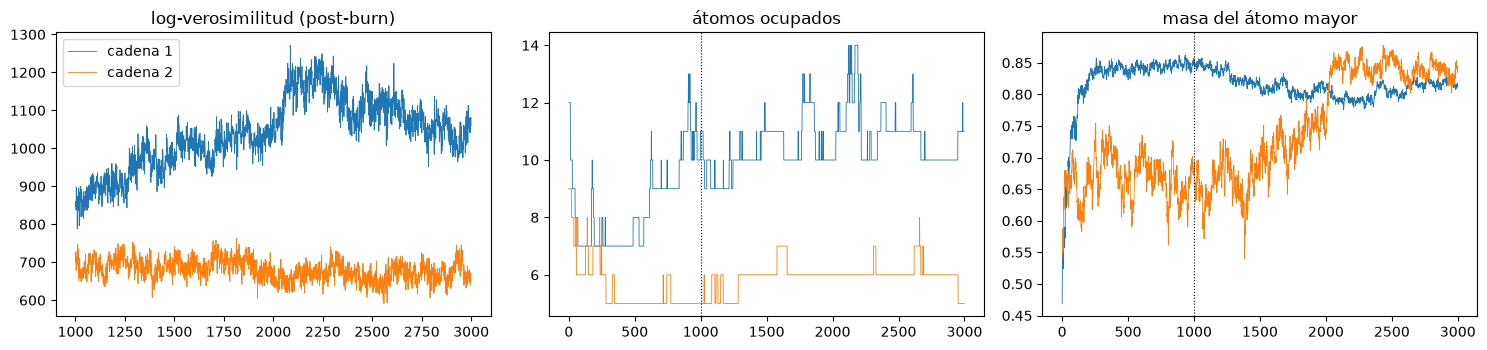

In [6]:
burn = CFG_MEZCLA.burn
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for t in TRAZAS:
    ax[0].plot(np.arange(burn, CFG_MEZCLA.n_iter), t["loglik"][burn:], lw=.6, label=f"cadena {t['cadena']}")
    ax[1].plot(t["n_ocupados"], lw=.6)
    ax[2].plot(t["masa_max"], lw=.6)
ax[0].set_title("log-verosimilitud (post-burn)"); ax[0].legend()
ax[1].set_title("átomos ocupados"); ax[2].set_title("masa del átomo mayor")
for a in ax[1:]:
    a.axvline(burn, color="k", ls=":", lw=.8)
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x01_convergencia_trazas.png", dpi=120)

MC = [mgp.media_condicional(t, DIS.X) for t in TRAZAS]     # (S, n, K) por cadena
te_rows = np.where(~TR)[0]
filas_ctrl = te_rows[np.linspace(0, te_rows.size - 1, 5).astype(int)]
filas_diag = [{"cantidad": "loglik", **diagnostico_variable(
    np.stack([t["loglik"][burn:] for t in TRAZAS]))}]
for i in filas_ctrl:
    for k in (0, 1):
        filas_diag.append({"cantidad": f"E[a{k + 1}|x] t={DIS.t_idx[i] + 1}",
                           **diagnostico_variable(np.stack([m[:, i, k] for m in MC]))})
DIAG = pd.DataFrame(filas_diag).set_index("cantidad")
DIAG.round(3)

## §6 Predicción a $h=1$ y referencias

- **mezcla_gp**: media predictiva y banda puntual por cuantiles de la predictiva muestral.
- **lineal_mco**: MCO sobre el **mismo** diseño, con banda gaussiana $\pm z\,\sqrt{\varphi(\tau)^\top\hat\Sigma\varphi(\tau)}$.
  Es la referencia lineal de este experimento, no el `FARp` del `_05`.
- **oraculo**: la media condicional verdadera del generador (sólo Bloque A). Es la cota de lo alcanzable.

In [7]:
X_obj = X_true[DIS.t_idx]                                   # objetivo: la curva (sigma_obs = 0)

# -- mezcla ----------------------------------------------------------------------
a_hat  = np.concatenate(MC).mean(axis=0)
X_mix  = mu_hat + a_hat @ Phi.T
rng_pred = np.random.default_rng(SEED + 17)
MUESTRAS = np.concatenate([mgp.muestras_predictivas(t, DIS.X, rng_pred) for t in TRAZAS])
li_mix, ls_mix = mgp.banda_funcional(MUESTRAS, Phi, mu_hat, NIVEL)

# -- lineal MCO, mismo diseno ---------------------------------------------------------
B_lin, *_ = np.linalg.lstsq(DIS.X[TR], DIS.Y[TR], rcond=None)
a_lin  = DIS.X @ B_lin
Sig_lin = np.cov((DIS.Y[TR] - a_lin[TR]).T)
X_lin  = mu_hat + a_lin @ Phi.T
sd_lin = np.sqrt(np.einsum("gk,kl,gl->g", Phi, Sig_lin, Phi))
z_ = 1.959963984540054
li_lin, ls_lin = X_lin - z_ * sd_lin, X_lin + z_ * sd_lin

# -- oraculo (internos, solo evaluacion) -----------------------------------------------
p_gen = cfg_sim.p_lags
At = salida.internos["A_tilde"][0]
m_imp = np.full(T_CURVAS, np.nan)
for t in range(p_gen, T_CURVAS):
    m_imp[t] = np.asarray(cfg_sim.phi) @ At[t - p_gen:t, 0][::-1]
a_or = np.zeros((T_CURVAS, J_BASE))
a_or[:, 0] = m_imp
a_or[:, 1] = salida.internos["oraculo"][0]
a_or *= np.sqrt(salida.internos["lambda"])[None, :]
X_or = (salida.media[None, :] + a_or @ Phi.T)[DIS.t_idx]
A_int = salida.internos["A"][0]
a_or_c = (a_or - A_int[:T0].mean(axis=0))[DIS.t_idx]      # misma escala centrada que COEF
HAY_ORACULO = N_LAGS >= p_gen
print(f"muestras predictivas {MUESTRAS.shape}   oraculo disponible: {HAY_ORACULO}")

muestras predictivas (1000, 995, 10)   oraculo disponible: True


### §6.1 ¿Capturó la no linealidad?

Esta figura es la prueba directa del experimento. Sobre los orígenes de test, compara
$E[\tilde a_{t,2}\mid\text{pasado}]$ contra el índice cuadrático verdadero $u^\top x$.

R2 test de a_2:  mezcla 0.044   lineal 0.043   oraculo 0.279


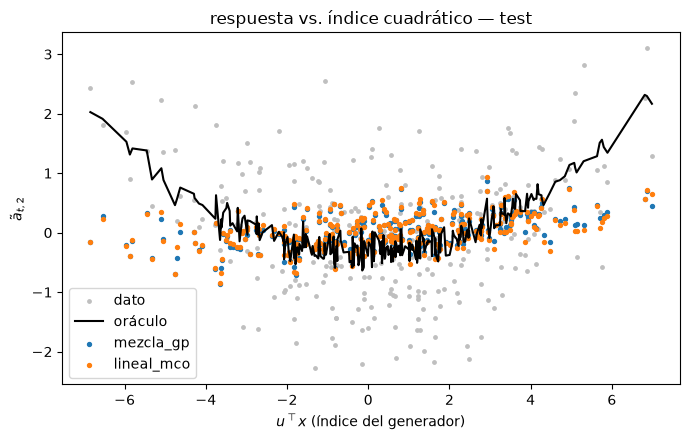

In [8]:
u = np.asarray(cfg_sim.u); v = cont["v_indice"]
lags_imp = np.column_stack([At[DIS.t_idx - l, 0] for l in range(1, p_gen + 1)])
indice = lags_imp @ u
sq = np.sqrt(salida.internos["lambda"][1])
te = ~TR
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(indice[te], DIS.Y[te, 1] / sq, s=6, c="0.75", label="dato")
o = np.argsort(indice[te])
ax.plot(indice[te][o], salida.internos["oraculo"][0][DIS.t_idx][te][o], "k", lw=1.5, label="oráculo")
ax.scatter(indice[te], a_hat[te, 1] / sq, s=8, label="mezcla_gp")
ax.scatter(indice[te], a_lin[te, 1] / sq, s=8, label="lineal_mco")
ax.set_xlabel(r"$u^\top x$ (índice del generador)"); ax.set_ylabel(r"$\tilde a_{t,2}$")
ax.legend(); ax.set_title("respuesta vs. índice cuadrático — test")
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x02_no_linealidad.png", dpi=120)

def r2(y, yhat):
    return 1 - np.mean((y - yhat) ** 2) / np.var(y)
y2 = DIS.Y[te, 1]
print(f"R2 test de a_2:  mezcla {r2(y2, a_hat[te, 1]):.3f}   lineal {r2(y2, a_lin[te, 1]):.3f}   "
      f"oraculo {r2(y2, a_or_c[te, 1]):.3f}")

## §7 Bloques A y B sobre la ventana móvil

Las ventanas se **leen** de `eval_config.json`. Las que cruzan `T0` se excluyen de todo agregado.

In [9]:
EVAL = cargar_config_evaluacion(PATHS)
VM = EVAL["ventana_movil"]
VENTANAS_W = VM["w"]
W_REF = VENTANAS_W[len(VENTANAS_W) // 2]

MODELOS = {"mezcla_gp": (X_mix, li_mix, ls_mix), "lineal_mco": (X_lin, li_lin, ls_lin)}
if HAY_ORACULO:
    MODELOS["oraculo"] = (X_or, None, None)

TABLAS = {}
for nombre, (Xp, li, ls) in MODELOS.items():
    for w in VENTANAS_W:
        tb = ventana_movil_funcional(X_obj, Xp, tau, DIS.T0_ev, w=w, paso=VM["paso"],
                                     solapadas=VM["solapadas"], t_offset=int(DIS.t_idx[0]),
                                     li=li, ls=ls, nivel=NIVEL, bloque_A=True)
        tb["modelo"], tb["w"] = nombre, w
        TABLAS[(nombre, w)] = tb
VM_TABLA = pd.concat(TABLAS.values(), ignore_index=True)
VM_TABLA = VM_TABLA[~VM_TABLA["cruza_T0"]]

# relaciones que no deben romperse (CLAUDE.md §3.1)
assert (VM_TABLA["mae_f"] <= VM_TABLA["l2_medio"] + 1e-12).all()
assert (VM_TABLA["l2_medio"] <= VM_TABLA["linf_medio"] + 1e-12).all()
assert (VM_TABLA["linf_medio"] <= VM_TABLA["linf_max"] + 1e-12).all()
con_banda = VM_TABLA["winkler"].notna() if "winkler" in VM_TABLA else None
vb = VM_TABLA[con_banda]
assert (vb["picp_simultaneo"] <= vb["picp"] + 1e-12).all()
assert (vb["winkler"] <= vb["winkler_max_medio"] + 1e-12).all()
assert (vb["winkler_max_medio"] <= vb["winkler_max_glob"] + 1e-12).all()

cols = METRICAS_A + METRICAS_B
RES = (VM_TABLA[VM_TABLA["w"] == W_REF]
       .groupby(["bloque", "modelo"])[[c for c in cols if c in VM_TABLA]]
       .mean().round(4))
RES

mae_f  rmse_f  linf_medio  linf_max    mpiw    picp  \
bloque modelo                                                             
test   lineal_mco  1.1395  1.4262      2.3989    4.5474  5.2778  0.9369   
       mezcla_gp   1.1424  1.4290      2.4071    4.5733  5.7539  0.9457   
       oraculo     1.0943  1.3743      2.3029    4.3544     NaN     NaN   
train  lineal_mco  1.0778  1.3493      2.3352    4.2701  5.2778  0.9516   
       mezcla_gp   1.0720  1.3421      2.3230    4.2326  5.6771  0.9639   
       oraculo     1.0621  1.3298      2.3069    4.2313     NaN     NaN   

                   picp_simultaneo  winkler  winkler_max_medio  \
bloque modelo                                                    
test   lineal_mco           0.6290   6.6801            15.7264   
       mezcla_gp            0.6535   6.9541            15.6831   
       oraculo                 NaN      NaN                NaN   
train  lineal_mco           0.6669   6.2102            13.3843   
       mezcla_gp            0.7179   6.3372            12.9364   
       oraculo                 NaN      NaN                NaN   

                   winkler_max_glob  
bloque modelo                        
test   lineal_mco           77.7417  
       mezcla_gp            77.9979  
       oraculo                  NaN  
train  lineal_mco           68.6142  
       mezcla_gp            60.7549  
       oraculo                  NaN

### §7.1 Quién gana cada ventana de test (`w = W_REF`, mezcla_gp vs lineal_mco)

In [10]:
def ganancias(w):
    a = VM_TABLA[(VM_TABLA.w == w) & (VM_TABLA.bloque == "test") & (VM_TABLA.modelo == "mezcla_gp")].set_index("t_centro")
    b = VM_TABLA[(VM_TABLA.w == w) & (VM_TABLA.bloque == "test") & (VM_TABLA.modelo == "lineal_mco")].set_index("t_centro")
    fila = {"w": w}
    for m in METRICAS_A + ["winkler", "winkler_max_medio", "winkler_max_glob"]:
        fila[m] = float((a[m] < b[m]).mean())
    for m in ("picp", "picp_simultaneo"):   # gana quien queda mas cerca del nominal
        fila[m] = float(((a[m] - NIVEL).abs() < (b[m] - NIVEL).abs()).mean())
    return fila
GANA = pd.DataFrame([ganancias(w) for w in VENTANAS_W]).set_index("w")
print("fraccion de ventanas de test en que mezcla_gp gana a lineal_mco (mpiw no rankea):")
GANA.round(3)

fraccion de ventanas de test en que mezcla_gp gana a lineal_mco (mpiw no rankea):


,mae_f,rmse_f,linf_medio,linf_max,winkler,winkler_max_medio,winkler_max_glob,picp,picp_simultaneo
w,,,,,,,,,
20,0.306,0.363,0.324,0.566,0.103,0.434,0.381,0.552,0.488
30,0.284,0.325,0.232,0.528,0.118,0.469,0.310,0.708,0.557
40,0.261,0.284,0.188,0.513,0.134,0.460,0.257,0.701,0.582


### §7.2 Resumen mín / máx / promedio en test (`w = W_REF`)

In [11]:
RESUMEN = (VM_TABLA[(VM_TABLA.w == W_REF) & (VM_TABLA.bloque == "test")]
           .groupby("modelo")[[c for c in cols if c in VM_TABLA]]
           .agg(["min", "max", "mean"]).T.round(4))
RESUMEN.to_csv(PATHS["out_report"] / "x03_resumen_test.csv")
RESUMEN

modelo                  lineal_mco  mezcla_gp  oraculo
mae_f             min       1.0074     1.0071   0.9299
                  max       1.3564     1.3616   1.2845
                  mean      1.1395     1.1424   1.0943
rmse_f            min       1.2573     1.2612   1.2073
                  max       1.6769     1.6882   1.5976
                  mean      1.4262     1.4290   1.3743
linf_medio        min       2.0731     2.0862   1.9545
                  max       2.6757     2.7049   2.6144
                  mean      2.3989     2.4071   2.3029
linf_max          min       3.5590     3.5008   3.3492
                  max       5.3487     5.4077   4.9988
                  mean      4.5474     4.5733   4.3544
mpiw              min       5.2778     5.6201      NaN
                  max       5.2778     5.9031      NaN
                  mean      5.2778     5.7539      NaN
picp              min       0.9031     0.8987      NaN
                  max       0.9658     0.9764      NaN
                  mean      0.9369     0.9457      NaN
picp_simultaneo   min       0.4333     0.4667      NaN
                  max       0.8000     0.8333      NaN
                  mean      0.6290     0.6535      NaN
winkler           min       5.6727     5.8939      NaN
                  max       8.0075     8.6737      NaN
                  mean      6.6801     6.9541      NaN
winkler_max_medio min      10.9810    10.5061      NaN
                  max      21.9681    21.2191      NaN
                  mean     15.7264    15.6831      NaN
winkler_max_glob  min      40.4597    32.6727      NaN
                  max     107.7331   114.6686      NaN
                  mean     77.7417    77.9979      NaN

## §8 Figuras

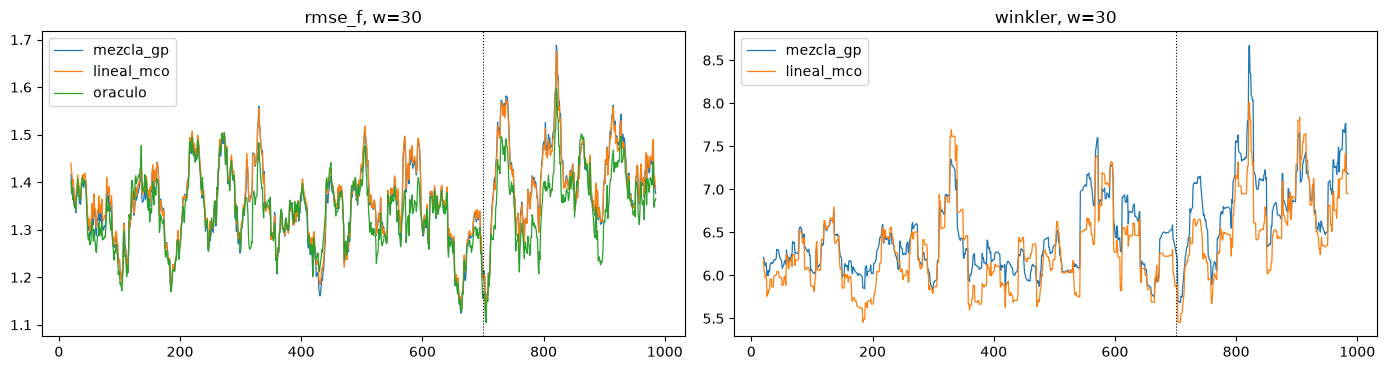

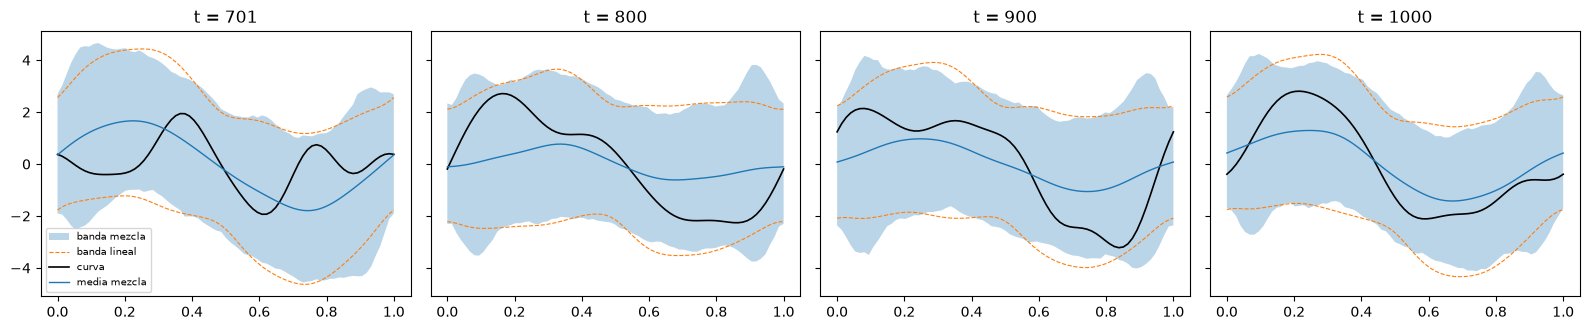

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
for nombre in MODELOS:
    tb = TABLAS[(nombre, W_REF)]
    ax[0].plot(tb["t_centro"], tb["rmse_f"], lw=.9, label=nombre)
    if nombre != "oraculo":
        ax[1].plot(tb["t_centro"], tb["winkler"], lw=.9, label=nombre)
for a, tit in zip(ax, ("rmse_f", "winkler")):
    a.axvline(T0, color="k", ls=":", lw=.8); a.set_title(f"{tit}, w={W_REF}"); a.legend()
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x04_ventana_movil.png", dpi=120)

ejemplos = te_rows[np.linspace(0, te_rows.size - 1, 4).astype(int)]
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4), sharey=True)
for a, i in zip(ax, ejemplos):
    a.fill_between(tau, li_mix[i], ls_mix[i], alpha=.3, label="banda mezcla")
    a.plot(tau, ls_lin[i], "C1--", lw=.8); a.plot(tau, li_lin[i], "C1--", lw=.8, label="banda lineal")
    a.plot(tau, X_obj[i], "k", lw=1.2, label="curva")
    a.plot(tau, X_mix[i], "C0", lw=1, label="media mezcla")
    a.set_title(f"t = {DIS.t_idx[i] + 1}")
ax[0].legend(fontsize=7)
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x05_curvas_test.png", dpi=120)